# Initial Analysis: Foreign Gifts to US Academic Institutions

This notebook answers the questions from `lab_01.ipynb`:

1. Load the Foreign Gifts data.
2. Describe the differences between different classes of gift types.
3. Answer the following questions:
    1. Which country gives the most money in total?
    2. Which country initiates the most gifts by count?
    3. Which country gives the largest gifts on average?
    4. Which institution receives the most money in total?
    5. Which institution receives the greatest number of gifts by count?
    6. What is the average amount each university receives? Median amount? If they are different why?
    7. What is the largest flow of a single country to a single institution?
    8. Which are the top giftors to US academic institutions?

## Setup: Imports and Loading Data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('ForeignGifts_edu.csv', low_memory=False)
print(df.shape)
df.head()

(28221, 10)


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


## Basic data exploration

Let's check column types, missing values, and the date column, which is stored as an Excel-style serial number.

In [2]:
df.info()
print()
print('Missing values per column:')
print(df.isna().sum())

# Convert Excel serial date to datetime for reference
df['Gift Date'] = pd.to_datetime(df['Foreign Gift Received Date'], unit='D', origin='1899-12-30')
df['Gift Year'] = df['Gift Date'].dt.year
df[['Foreign Gift Received Date', 'Gift Date', 'Gift Year']].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28221 entries, 0 to 28220
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          28221 non-null  int64 
 1   OPEID                       28221 non-null  int64 
 2   Institution Name            28221 non-null  object
 3   City                        28221 non-null  object
 4   State                       28221 non-null  object
 5   Foreign Gift Received Date  28221 non-null  int64 
 6   Foreign Gift Amount         28221 non-null  int64 
 7   Gift Type                   28221 non-null  object
 8   Country of Giftor           28221 non-null  object
 9   Giftor Name                 24470 non-null  object
dtypes: int64(4), object(6)
memory usage: 2.2+ MB

Missing values per column:
ID                               0
OPEID                            0
Institution Name                 0
City                             0
S

,Foreign Gift Received Date,Gift Date,Gift Year
0,43738,2019-09-30,2019
1,43592,2019-05-07,2019
2,43466,2019-01-01,2019
3,43472,2019-01-07,2019
4,43479,2019-01-14,2019


## Task 2: Differences between gift types

The data records two main types of foreign support: **Monetary Gift** (a direct cash gift/donation) and **Contract** (a paid agreement for goods/services, e.g. sponsored research or licensing). Let's compare their counts and amounts.

In [3]:
print(df['Gift Type'].value_counts())
print()

gift_type_summary = df.groupby('Gift Type')['Foreign Gift Amount'].describe()
gift_type_summary



Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64



,count,mean,std,min,25%,50%,75%,max
Gift Type,,,,,,,,
Contract,"17,274.00","625,794.51","3,768,216.87","-537,770.00","13,757.50","110,000.00","366,000.00","99,999,999.00"
Monetary Gift,"10,936.00","528,150.44","2,086,487.12",1.00,250.00,"50,000.00","400,000.00","48,842,186.00"
Real Estate,11.00,"1,335,265.45","1,412,070.57","39,456.00","370,574.50","667,555.00","2,121,736.00","4,312,000.00"


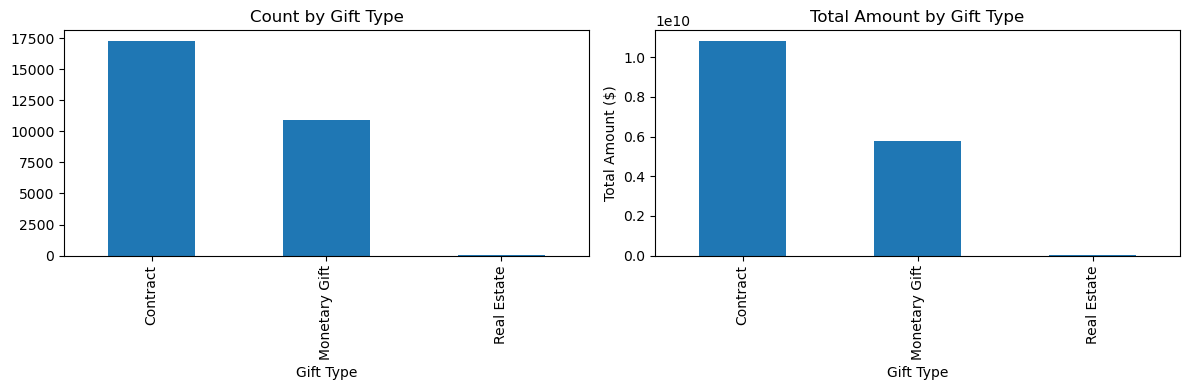

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Gift Type'].value_counts().plot(kind='bar', ax=axes[0], title='Count by Gift Type')
df.groupby('Gift Type')['Foreign Gift Amount'].sum().plot(kind='bar', ax=axes[1], title='Total Amount by Gift Type')
axes[1].set_ylabel('Total Amount ($)')
plt.tight_layout()
plt.show()

## Question 1: Which country gives the most money in total?

       Country of Giftor  Foreign Gift Amount
0                  QATAR           2706240869
1                ENGLAND           1464906771
2                  CHINA           1237952112
3           SAUDI ARABIA           1065205930
4                BERMUDA            899593972
5                 CANADA            898160656
6              HONG KONG            887402529
7                  JAPAN            655954776
8            SWITZERLAND            619899445
9                  INDIA            539556490
10               GERMANY            442475605
11  UNITED ARAB EMIRATES            431396357
12                FRANCE            405839396
13             SINGAPORE            401157692
14             AUSTRALIA            248409202


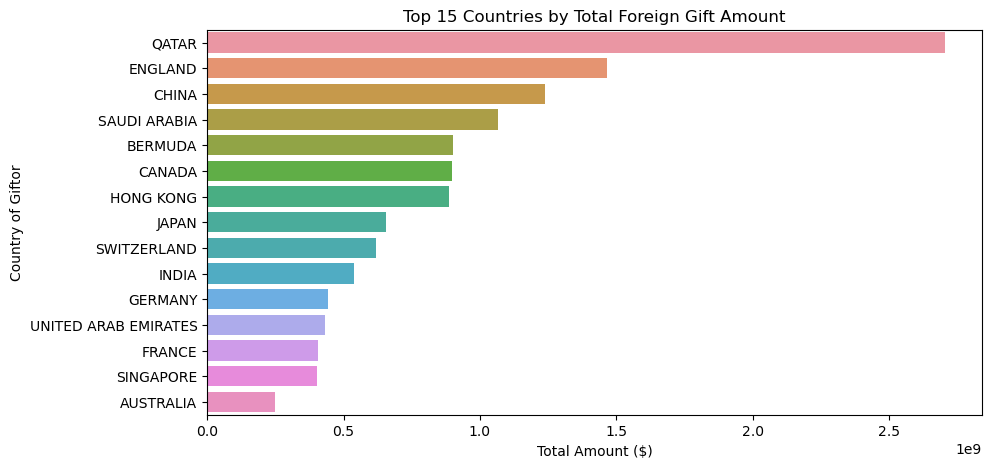

In [5]:
country_totals = (
    df.groupby('Country of Giftor')['Foreign Gift Amount']
      .sum()
      .nlargest(15)
      .reset_index()
)
print(country_totals)

plt.figure(figsize=(10, 5))
sns.barplot(data=country_totals, x='Foreign Gift Amount', y='Country of Giftor')
plt.title('Top 15 Countries by Total Foreign Gift Amount')
plt.xlabel('Total Amount ($)')
plt.show()

## Question 2: Which country initiates the most gifts by count?

   Country of Giftor  Gift Count
0            ENGLAND        3655
1              CHINA        2461
2             CANADA        2344
3              JAPAN        1896
4        SWITZERLAND        1676
5       SAUDI ARABIA        1610
6             FRANCE        1437
7            GERMANY        1394
8          HONG KONG        1080
9        SOUTH KOREA         811
10             QATAR         693
11   THE NETHERLANDS         512
12             KOREA         452
13             INDIA         434
14            TAIWAN         381


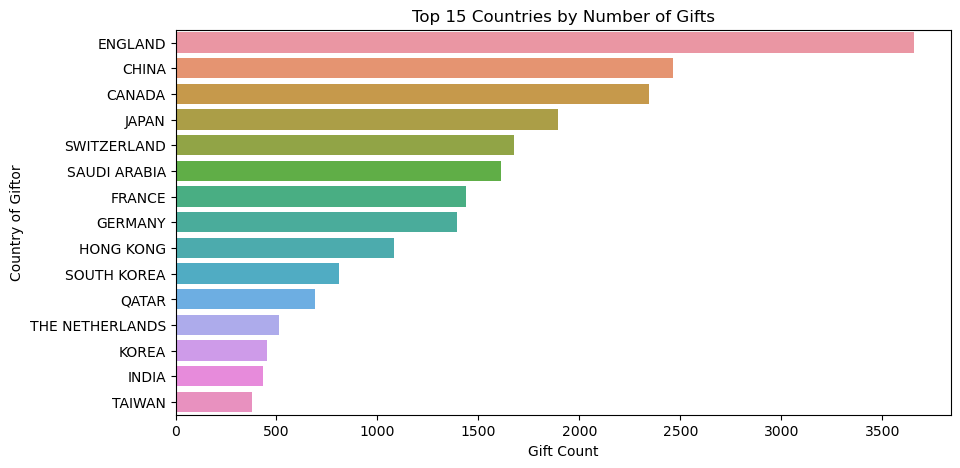

In [6]:
country_counts = (
    df.groupby('Country of Giftor')['Foreign Gift Amount']
      .count()
      .nlargest(15)
      .reset_index()
      .rename(columns={'Foreign Gift Amount': 'Gift Count'})
)
print(country_counts)

plt.figure(figsize=(10, 5))
sns.barplot(data=country_counts, x='Gift Count', y='Country of Giftor')
plt.title('Top 15 Countries by Number of Gifts')
plt.show()

## Question 3: Which country gives the largest gifts on average?

To avoid noise from countries with only a couple of gifts, we require at least 10 gifts to qualify.

                                 mean  count
Country of Giftor                           
BERMUDA                  7,688,837.37    117
QATAR                    3,905,109.48    693
RUSSIA                   2,025,462.38     50
IRAQ                     1,665,520.00     27
RWANDA                   1,425,200.92     26
GREECE                   1,416,482.50     38
GEORGIA                  1,302,540.80     45
KAZAKHSTAN               1,298,234.69     48
INDIA                    1,243,217.72    434
UNITED ARAB EMIRATES     1,181,907.83    365
MONACO                   1,156,975.09     55
SINGAPORE                1,114,326.92    360
PORTUGAL                 1,093,116.18     33
VIRGIN ISLANDS (BRITISH) 1,036,197.85     13
BURMA                    1,028,681.10     10


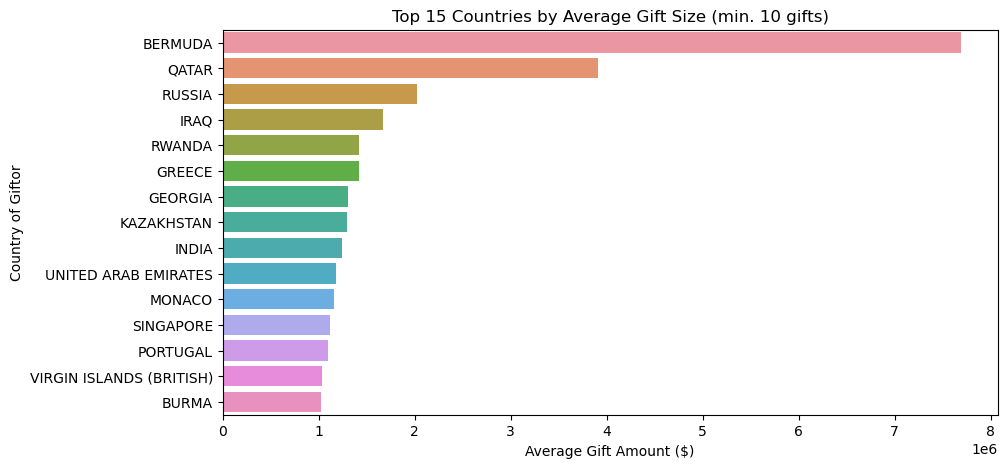

In [7]:
country_stats = df.groupby('Country of Giftor')['Foreign Gift Amount'].agg(['mean', 'count'])
country_avg_qualified = (
    country_stats[country_stats['count'] >= 10]
    .sort_values('mean', ascending=False)
    .head(15)
)
print(country_avg_qualified)

plt.figure(figsize=(10, 5))
sns.barplot(x=country_avg_qualified['mean'], y=country_avg_qualified.index)
plt.title('Top 15 Countries by Average Gift Size (min. 10 gifts)')
plt.xlabel('Average Gift Amount ($)')
plt.show()

## Question 4 & 5: Which institutions receive the most money / the greatest number of gifts?

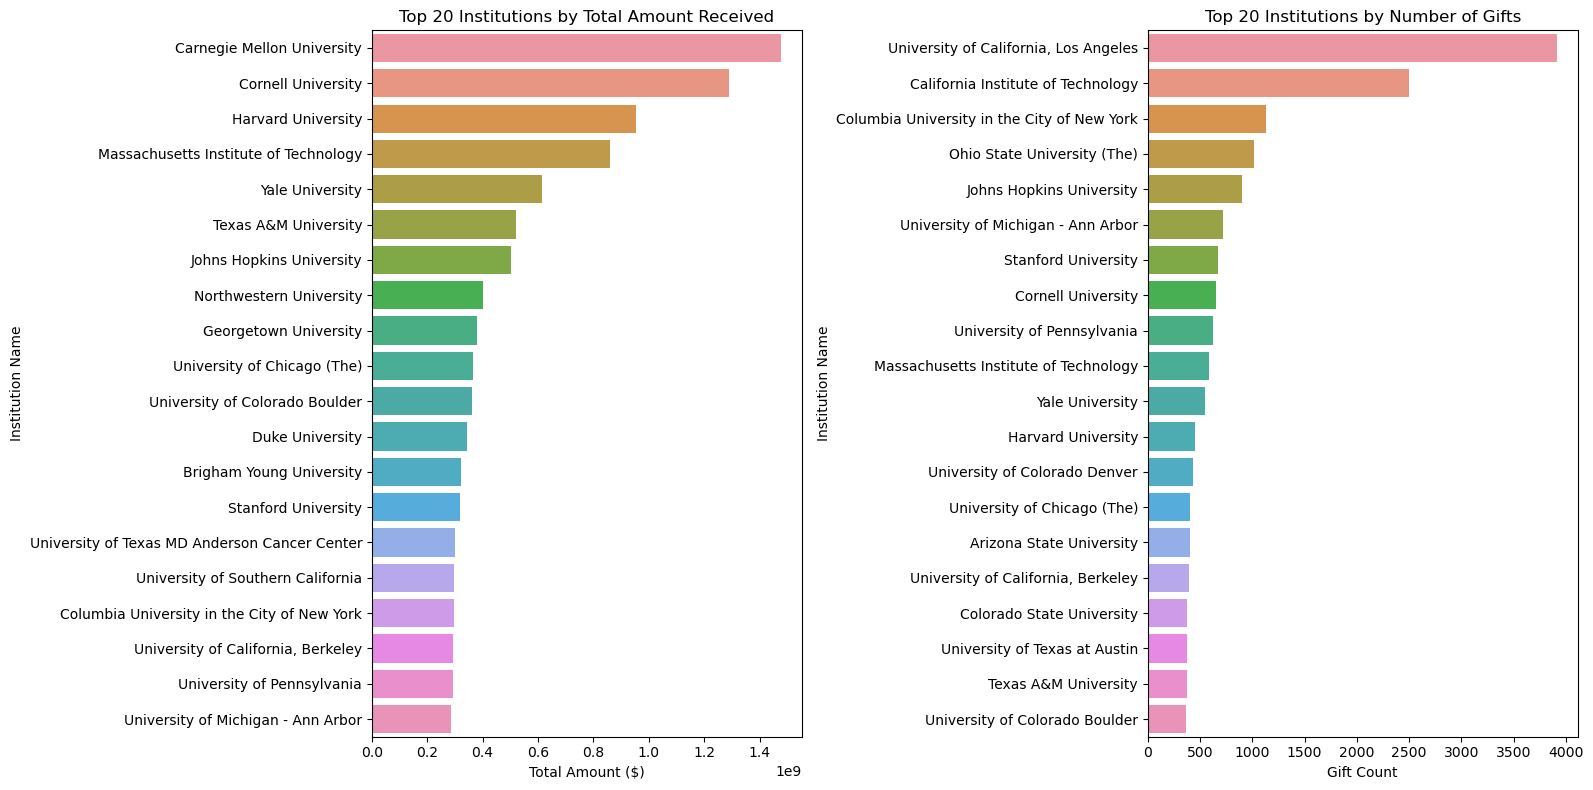

                                 Institution Name  Foreign Gift Amount
0                      Carnegie Mellon University           1477922504
1                              Cornell University           1289937761
2                              Harvard University            954803610
3           Massachusetts Institute of Technology            859071692
4                                 Yale University            613441311
5                            Texas A&M University            521455050
6                        Johns Hopkins University            502409595
7                         Northwestern University            402316221
8                           Georgetown University            379950511
9                     University of Chicago (The)            364544338
10                 University of Colorado Boulder            360173159
11                                Duke University            343699498
12                       Brigham Young University            323509863
13    

In [8]:
inst_totals = (
    df.groupby('Institution Name')['Foreign Gift Amount']
      .sum()
      .nlargest(20)
      .reset_index()
)

inst_counts = (
    df.groupby('Institution Name')['Foreign Gift Amount']
      .count()
      .nlargest(20)
      .reset_index()
      .rename(columns={'Foreign Gift Amount': 'Gift Count'})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(data=inst_totals, x='Foreign Gift Amount', y='Institution Name', ax=axes[0])
axes[0].set_title('Top 20 Institutions by Total Amount Received')
axes[0].set_xlabel('Total Amount ($)')

sns.barplot(data=inst_counts, x='Gift Count', y='Institution Name', ax=axes[1])
axes[1].set_title('Top 20 Institutions by Number of Gifts')

plt.tight_layout()
plt.show()

print(inst_totals)
print()
print(inst_counts)

## Question 6: Average vs. Median amount received per university

We first aggregate to total amount received per university (across all its gifts), then look at the distribution of those totals across universities.

Mean total received per university:   $52,202,878.97
Median total received per university: $6,486,791.50


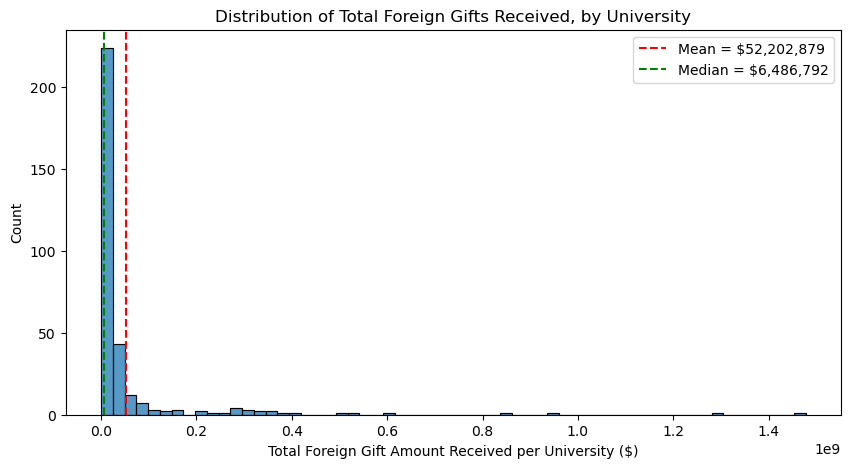

In [9]:
univ_totals = df.groupby('Institution Name')['Foreign Gift Amount'].sum()

mean_amt = univ_totals.mean()
median_amt = univ_totals.median()

print(f'Mean total received per university:   ${mean_amt:,.2f}')
print(f'Median total received per university: ${median_amt:,.2f}')

plt.figure(figsize=(10, 5))
sns.histplot(univ_totals, bins=60)
plt.axvline(mean_amt, color='red', linestyle='--', label=f'Mean = ${mean_amt:,.0f}')
plt.axvline(median_amt, color='green', linestyle='--', label=f'Median = ${median_amt:,.0f}')
plt.xlabel('Total Foreign Gift Amount Received per University ($)')
plt.legend()
plt.title('Distribution of Total Foreign Gifts Received, by University')
plt.show()

**Why are the mean and median different?** The distribution of total gifts received per university is heavily right-skewed: a small number of large research universities (e.g. Harvard, MIT, major state flagships) receive enormous sums from foreign contracts and gifts, while the vast majority of universities receive relatively modest amounts. These few very large outliers pull the mean well above the median, which is a more robust indicator of the "typical" university's foreign gift total.

## Question 7: Largest flow of money from a single country to a single institution

First, use `pd.crosstab` (weighted by amount) to look at the relationship between countries and institutions, then find the single largest country → institution flow.

In [10]:
# Crosstab weighted by gift amount (country x institution), restricted to
# the top countries/institutions by total amount to keep it readable
top_countries = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().nlargest(10).index
top_institutions = df.groupby('Institution Name')['Foreign Gift Amount'].sum().nlargest(10).index

sub = df[df['Country of Giftor'].isin(top_countries) & df['Institution Name'].isin(top_institutions)]

flow_table = pd.crosstab(
    sub['Country of Giftor'],
    sub['Institution Name'],
    values=sub['Foreign Gift Amount'],
    aggfunc='sum'
).fillna(0)

flow_table

Institution Name,Carnegie Mellon University,Cornell University,Georgetown University,Harvard University,Johns Hopkins University,Massachusetts Institute of Technology,Northwestern University,Texas A&M University,University of Chicago (The),Yale University
Country of Giftor,,,,,,,,,,
BERMUDA,"750,000,000.00","980,000.00",0.00,"4,127,000.00","893,384.00","5,500,000.00",0.00,0.00,0.00,"1,002,500.00"
CANADA,"13,605,711.00","21,730,083.00",0.00,"31,147,133.00","49,193,636.00","5,275,433.00","5,712,410.00","305,334.00","5,859,140.00","11,484,325.00"
CHINA,"20,892,044.00","27,864,330.00","4,539,621.00","87,165,906.00","10,390,321.00","47,906,641.00","5,548,047.00","5,264,930.00","51,941,861.00","78,160,274.00"
ENGLAND,"4,640,165.00","12,492,789.00","6,130,564.00","188,328,288.00","64,872,564.00","70,307,241.00","4,315,048.00","719,935.00","92,454,540.00","107,303,970.00"
HONG KONG,"13,750,000.00","33,440,603.00","7,531,000.00","140,275,479.00","1,144,915.00","65,661,712.00","3,250,100.00",0.00,"42,368,948.00","161,131,218.00"
INDIA,"32,323,000.00","49,563,977.00",0.00,"38,436,383.00","21,517,169.00","40,673,600.00","869,643.00",0.00,"13,937,110.00","13,744,611.00"
JAPAN,"30,913,374.00","10,192,678.00","5,000,000.00","17,359,425.00","30,061,618.00","46,586,288.00","4,123,118.00","426,787.00","20,465,588.00","8,863,156.00"
QATAR,"425,410,702.00","1,018,473,315.00","327,128,310.00","5,077,754.00","1,917,837.00",0.00,"311,148,564.00","504,099,350.00","946,460.00","284,668.00"
SAUDI ARABIA,"1,050,000.00","2,579,426.00","6,000,000.00","28,655,079.00","10,544,925.00","89,435,405.00","14,553,243.00","9,300,602.00","1,419,786.00","9,947,006.00"


In [11]:
# Find the single largest country -> institution flow across the FULL dataset
flows = (
    df.groupby(['Country of Giftor', 'Institution Name'])['Foreign Gift Amount']
      .sum()
      .nlargest(10)
      .reset_index()
)
flows

,Country of Giftor,Institution Name,Foreign Gift Amount
0,QATAR,Cornell University,1018473315
1,BERMUDA,Carnegie Mellon University,750000000
2,QATAR,Texas A&M University,504099350
3,QATAR,Carnegie Mellon University,425410702
4,QATAR,Georgetown University,327128310
5,QATAR,Northwestern University,311148564
6,CANADA,Brigham Young University,259927758
7,UNITED ARAB EMIRATES,University of Colorado Boulder,219734835
8,ENGLAND,Harvard University,188328288
9,HONG KONG,Yale University,161131218


### Visualizing flows with an alluvial (Sankey) diagram

To better visualize which countries money is flowing from and which institutions it flows into, we use an alluvial diagram via `plotly`.

In [12]:
import plotly.graph_objects as go

giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow_col = 'Foreign Gift Amount'
N = 25

flows_top = (
    df.groupby([giftor, recipi])[flow_col]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = flows_top[giftor].tolist() + flows_top[recipi].tolist()
labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels, pad=15),
        link=dict(
            source=flows_top[giftor].map(labels.index),
            target=flows_top[recipi].map(labels.index),
            value=flows_top[flow_col]
        )
    )
)
fig.update_layout(title_text=f'Top {N} Country \u2192 Institution Gift Flows', font_size=10)
fig.show()

## Question 8: Top giftors to US academic institutions

`Giftor Name` is only populated for a subset of records (many gifts, especially straightforward monetary gifts, do not name an individual/organization giftor). We restrict to non-missing giftor names and rank by total amount given.

24,470 of 28,221 gifts (86.7%) have a named giftor
                            Giftor Name  Foreign Gift Amount
0                      Qatar Foundation           1166503744
1   Qatar Foundation/Qatar National Res            796197000
2        Qatar Foundation for Education            373945215
3                             Anonymous            338793629
4        Saudi Arabian Cultural Mission            275221475
5                                   HCL            190000000
6         Church of Jesus Christ of LDS            185203715
7    Emirates Institute for Advanced Sc            170641244
8                                   QIC            148355497
9                          Anonymous #9             96334996
10         Qatar National Research Fund             79021705
11           Government of Saudi Arabia             75192434
12                    Contracting Party             69996984
13                      CMKL University             67700000
14        Royal Embassy of Saudi A

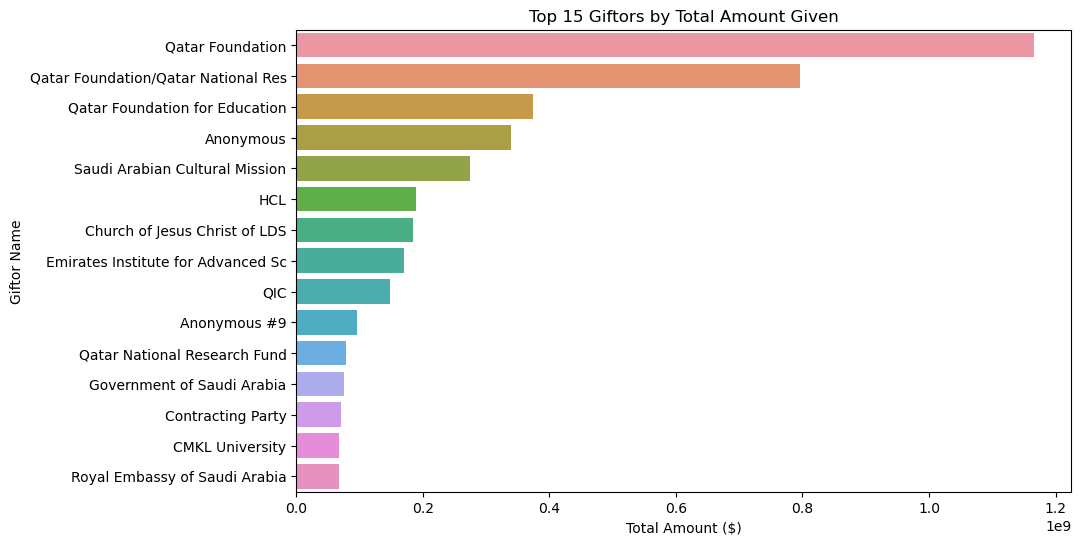

In [13]:
named_giftors = df[df['Giftor Name'].notna() & (df['Giftor Name'].str.strip() != '')]
print(f"{len(named_giftors):,} of {len(df):,} gifts ({len(named_giftors)/len(df):.1%}) have a named giftor")

top_giftors_amt = (
    named_giftors.groupby('Giftor Name')['Foreign Gift Amount']
    .sum()
    .nlargest(15)
    .reset_index()
)

top_giftors_count = (
    named_giftors.groupby('Giftor Name')['Foreign Gift Amount']
    .count()
    .nlargest(15)
    .reset_index()
    .rename(columns={'Foreign Gift Amount': 'Gift Count'})
)

print(top_giftors_amt)
print()
print(top_giftors_count)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_giftors_amt, x='Foreign Gift Amount', y='Giftor Name')
plt.title('Top 15 Giftors by Total Amount Given')
plt.xlabel('Total Amount ($)')
plt.show()